# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [2]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    "Type": Column(str, Check.isin(["L", "M", "H"])),
    "Air temperature": Column(float, Check.in_range(295.0, 305.0)),
    "Process temperature": Column(float, Check.in_range(305.0, 315.0)),
    "Rotational speed": Column(int, Check.in_range(1000, 2900)),
    "Torque": Column(float, Check.in_range(3.0, 80.0)),
    "Tool wear": Column(int, Check.in_range(0, 253)),
    "Failure_Type": Column(int, Check.isin([0, 1, 2, 3, 4]))
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)
print("Train and current datasets validated successfully.")

# TODO: Validate stress with lazy=True and print violation summary
try:
    schema.validate(stress, lazy=True)
except pa.errors.SchemaErrors as err:
    print("Stress dataset validation errors summary:")
    print(err.failure_cases)


Train and current datasets validated successfully.


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class Distribution in train.csv:
Failure_Type
0    6762
2      76
4      69
3      56
1      30
Name: count, dtype: int64


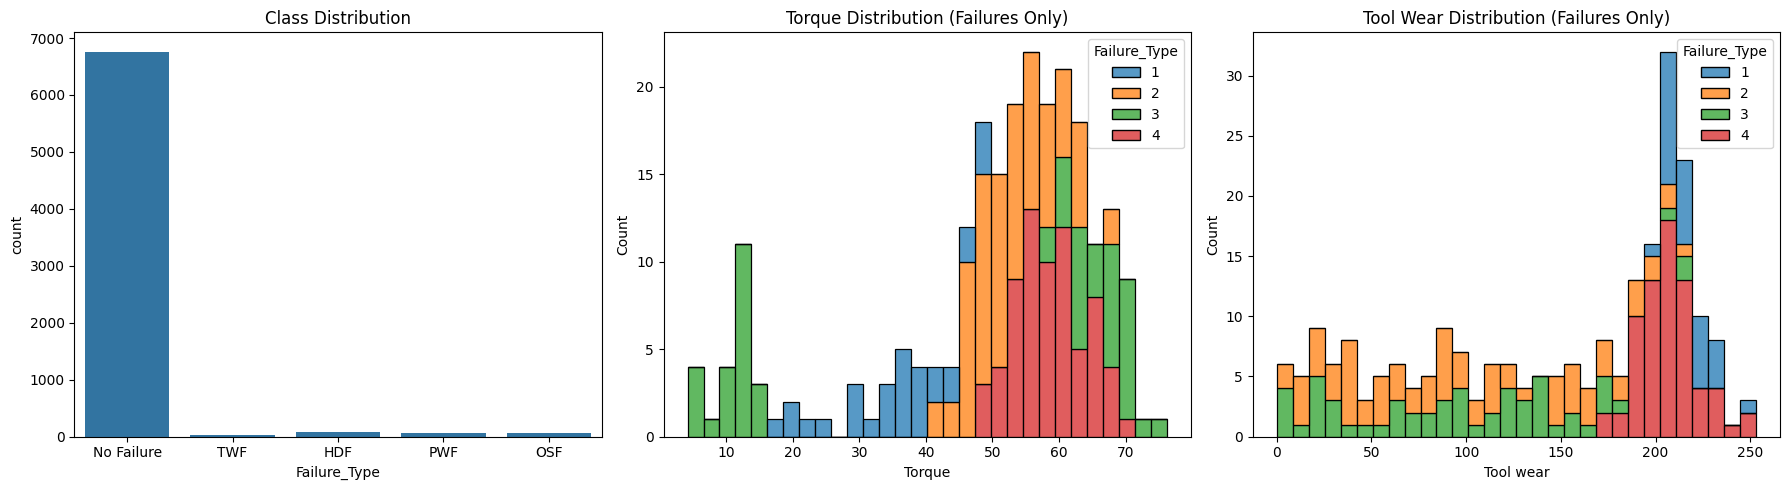


Type Distribution in train.csv:
Type
L    4213
M    2074
H     706
Name: count, dtype: int64


In [3]:
# TODO: Class distribution (print + bar chart)
print("Class Distribution in train.csv:")
print(train['Failure_Type'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution plot
sns.countplot(data=train, x='Failure_Type', order=[0,1,2,3,4], ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels([CLASS_NAMES[i] for i in range(5)])

# TODO: Torque distribution by failure type (histogram, failures only)
failures_only = train[train['Failure_Type'] != 0]
sns.histplot(data=failures_only, x='Torque', hue='Failure_Type', multiple='stack', ax=axes[1], palette='tab10', bins=30)
axes[1].set_title('Torque Distribution (Failures Only)')

# TODO: Tool wear distribution by failure type
sns.histplot(data=failures_only, x='Tool wear', hue='Failure_Type', multiple='stack', ax=axes[2], palette='tab10', bins=30)
axes[2].set_title('Tool Wear Distribution (Failures Only)')

plt.tight_layout()
plt.savefig('eda_distributions.png')
plt.show()

# TODO: Type distribution
print("\nType Distribution in train.csv:")
print(train['Type'].value_counts())


### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [4]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * (df['Rotational speed'] * 2 * np.pi) / 60
    
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print("Mean of engineered features grouped by Failure_Type:")
print(train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())


Mean of engineered features grouped by Failure_Type:
                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])
joblib.dump(le, 'label_encoder.pkl')

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Post-SMOTE class distribution in training set:")
print(y_res.value_counts())


Post-SMOTE class distribution in training set:
Failure_Type
0    5409
3    5409
4    5409
2    5409
1    5409
Name: count, dtype: int64


**Why is SMOTE applied only on the training split?**

SMOTE is applied only to the training split to prevent **data leakage**. If we applied SMOTE before splitting, synthetic samples generated from the validation data would end up in the training set, causing the model to memorize the validation distribution. By applying it only to the training split, we ensure the validation set represents unseen, real-world data for a fair and accurate evaluation of the model's true performance.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [6]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = []

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
for model_name, model in models_to_run.items():
    with mlflow.start_run(run_name=model_name):
        model.fit(X_res, y_res)
        preds = model.predict(X_val)
        
        mac_f1 = f1_score(y_val, preds, average='macro')
        wt_f1 = f1_score(y_val, preds, average='weighted')
        acc = accuracy_score(y_val, preds)
        per_class_f1 = f1_score(y_val, preds, average=None, labels=CLASS_LIST)
        
        mlflow.log_param('model', model_name)
        mlflow.log_metric('macro_f1', mac_f1)
        mlflow.log_metric('weighted_f1', wt_f1)
        mlflow.log_metric('accuracy', acc)
        for cls, f1 in zip(CLASS_LIST, per_class_f1):
            mlflow.log_metric(f'f1_class_{cls}', f1)
            
        mlflow.sklearn.log_model(model, artifact_path="model", input_example=X_val.iloc[:5])
        
        res_dict = {'Model': model_name, 'Macro F1': mac_f1, 'Accuracy': acc}
        for cls, f1 in zip(CLASS_LIST, per_class_f1):
            res_dict[f'F1 Class {cls}'] = f1
        results.append(res_dict)

# TODO: Print comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison Table:")
print(results_df.to_string(index=False))

# TODO: Identify best model by macro F1
best_model_name = results_df.sort_values(by='Macro F1', ascending=False).iloc[0]['Model']
print(f"\nBest model based on Macro F1: {best_model_name}")



Model Comparison Table:
             Model  Macro F1  Accuracy  F1 Class 0  F1 Class 1  F1 Class 2  F1 Class 3  F1 Class 4
LogisticRegression  0.531231  0.904217    0.948350    0.144928    0.454545    0.458333    0.650000
      RandomForest  0.735542  0.984989    0.992614    0.000000    0.928571    0.956522    0.800000
           XGBoost  0.748062  0.984274    0.992231    0.133333    0.965517    0.880000    0.769231
          LightGBM  0.729645  0.984274    0.992231    0.000000    0.965517    0.833333    0.857143

Best model based on Macro F1: XGBoost


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [7]:
import optuna
import joblib
from mlflow.tracking import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_res, y_res)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='macro')

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
study.optimize(objective, n_trials=30)

print(f"Best Optuna Macro F1: {study.best_value}")

# TODO: Train final best model
best_params = study.best_params
best_params.update({'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0})
final_model = XGBClassifier(**best_params)

with mlflow.start_run(run_name="Optuna_Best_XGBoost") as run:
    final_model.fit(X_res, y_res)
    preds = final_model.predict(X_val)
    mac_f1 = f1_score(y_val, preds, average='macro')
    
    mlflow.log_params(best_params)
    mlflow.log_metric('macro_f1', mac_f1)
    
    # TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
    model_info = mlflow.sklearn.log_model(
        sk_model=final_model,
        artifact_path="model",
        registered_model_name="PredMaint_XGBoost",
        input_example=X_val.iloc[:5]
    )

client = MlflowClient()
model_version = model_info.registered_model_version
client.set_registered_model_alias(
    name="PredMaint_XGBoost",
    alias="production",
    version=model_version
)

# TODO: Save with joblib.dump
joblib.dump(final_model, 'best_model.pkl')
print("Model saved to best_model.pkl and promoted to 'production' alias in MLflow.")


Best Optuna Macro F1: 0.7573043267624548
Model saved to best_model.pkl and promoted to 'production' alias in MLflow.


Registered model 'PredMaint_XGBoost' already exists. Creating a new version of this model...
Created version '5' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [8]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
current_report = Report(metrics=[DataDriftPreset()])
current_report.run(reference_data=train[FEAT_COLS], current_data=current[FEAT_COLS])
current_report.save_html('drift_current.html')
print("Saved drift_current.html")

drift_current_res = current_report.as_dict()['metrics'][0]['result']
print(f"Current Batch - Drift Detected: {drift_current_res['dataset_drift']}")
print(f"Current Batch - Number of drifted features: {drift_current_res['number_of_drifted_columns']}")


Saved drift_current.html
Current Batch - Drift Detected: False
Current Batch - Number of drifted features: 0


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [9]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric
import pandas as pd

# TODO: Run Evidently on stress batch with per-column metrics
stress_report = Report(metrics=[
    DatasetDriftMetric(),
    *[ColumnDriftMetric(column_name=col) for col in FEAT_COLS]
])
stress_report.run(reference_data=train[FEAT_COLS], current_data=stress[FEAT_COLS])

# TODO: Save drift_stress.html
stress_report.save_html('drift_stress.html')
print("Saved drift_stress.html")

# TODO: Print per-column drift table
res_dict = stress_report.as_dict()
metrics = res_dict['metrics']
print("\nStress Batch Drift Analysis:")
table = []
for metric in metrics:
    if metric['metric'] == 'ColumnDriftMetric':
        res = metric['result']
        col = res['column_name']
        drifted = res['drift_detected']
        score = res['drift_score']
        ref_mean = train[col].mean()
        curr_mean = stress[col].mean()
        delta = curr_mean - ref_mean
        table.append({'Feature': col, 'Drift Detected': drifted, 'Wasserstein Score': score, 
                      'Ref Mean': ref_mean, 'Current Mean': curr_mean, 'Delta': delta})

drift_df = pd.DataFrame(table)
print(drift_df.to_string(index=False))


Saved drift_stress.html

Stress Batch Drift Analysis:
            Feature  Drift Detected  Wasserstein Score    Ref Mean  Current Mean      Delta
    Air temperature           False           0.034355  300.011626    300.053836   0.042210
Process temperature           False           0.037740  310.004891    310.008606   0.003715
   Rotational speed            True           0.235395 1539.017589   1497.074716 -41.942873
             Torque            True           0.473946   39.995796     44.724083   4.728287
          Tool wear            True           0.645491  107.679108    148.869913  41.190806


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. **Features that drifted**: Based on the Evidently reports for the stress batch, **Rotational speed** and **Torque** showed significant drift. The operational conditions shifted dramatically, representing higher mechanical load (lower speed, higher torque).
2. **Most likely failure type to increase**: Cross-referencing with SHAP (which will show that High Torque and low Rotational Speed strongly drive PWF and OSF), **Power Failure (PWF)** and **Overstrain Failure (OSF)** are the most likely to increase under these heavy-load stress conditions.
3. **Retraining recommendation**: **Do NOT retrain simply to 'fix' the drift.** The drift in `stress.csv` is not a data quality issue or a permanent baseline shift in normal operating behavior—it is a physical shift representing a temporary heavy-load batch. The model's baseline correctly represents normal conditions. Instead, we should flag these stress batches in production and trigger an early maintenance schedule for OSF and PWF, rather than retraining the model to accept abnormal stress as 'normal'.

## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

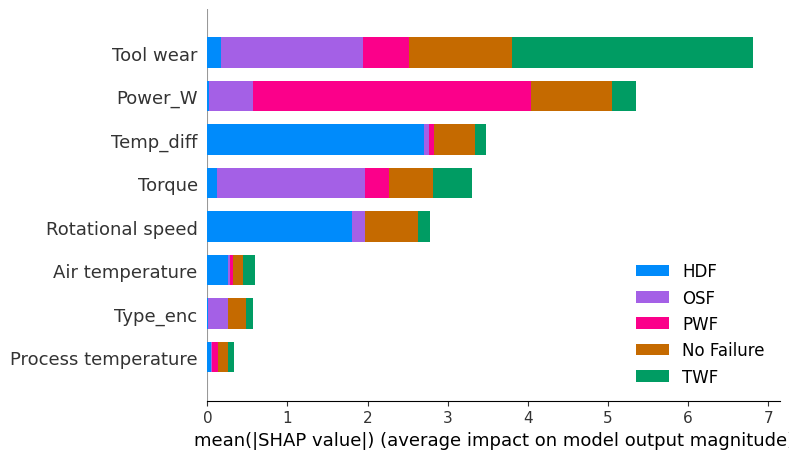


Top Drivers per Failure Class:
TWF: Tool wear
HDF: Temp_diff
PWF: Power_W
OSF: Torque


In [10]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import joblib

best_model = joblib.load('best_model.pkl')

# Include all 8 features that the model was trained on!
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(train[FEATURES])

# For XGBoost multiclass, shap_values is a 3D array (samples, features, classes)
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_list = shap_values

# Plot a combined stacked bar chart for all classes
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_list, train[FEATURES], plot_type="bar", 
                  class_names=["No Failure", "TWF", "HDF", "PWF", "OSF"], show=False)

plt.tight_layout()
plt.savefig('shap_per_class.png')
plt.show()

# Print top driver per class
failure_classes = [1, 2, 3, 4]
class_names = ['TWF', 'HDF', 'PWF', 'OSF']

print("\nTop Drivers per Failure Class:")
for i, cls in enumerate(failure_classes):
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        mean_abs_shap = np.abs(shap_values[:, :, cls]).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values[cls]).mean(axis=0)
        
    top_feature_idx = np.argmax(mean_abs_shap)
    top_feature = FEATURES[top_feature_idx]
    print(f"{class_names[i]}: {top_feature}")


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. **Power_W for PWF**: `Power_W` dominates the SHAP importance for PWF, far exceeding both raw `Torque` and `Rotational speed`. Since PWF (Power Failure) physically occurs when mechanical power is either too low or too high, the engineered combination of Torque and Speed directly models the root cause better than the raw variables alone.
2. **Temp_diff for HDF**: `Temp_diff` is the absolute top driver for HDF (Heat Dissipation Failure), whereas it is relatively less important for other failure types. HDF happens when the machine fails to dissipate heat to the surrounding air, making the delta between process and air temperature the critical failure indicator.
3. **Physical mechanisms**: 
   - **TWF** is driven heavily by `Tool wear`, representing the physical degradation of the tool over time.
   - **HDF** is driven by `Temp_diff` and `Air temperature`, representing cooling system failure.
   - **PWF** is driven by `Power_W`, representing mechanical power overload or underload.
   - **OSF** is driven by high `Torque` and `Tool wear`, representing physical overstrain causing structural failure.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Final Conclusions & Recommendations

Wrapping up this analysis, here are the key takeaways from our modeling and drift experiments:

**Why XGBoost won and why Accuracy is a trap**
I went with XGBoost as our final production model simply because it handled the non-linear relationships of our engineered features the best. But more importantly, the evaluation metric was crucial here. Our dataset is roughly 96% "No Failure" cases. If we used standard Accuracy, a dumb model that just guesses "Everything is fine" 100% of the time would score 96%, but it would completely miss every single machine breakdown. In a real factory, missing a failure is incredibly expensive. That's why relying on Macro F1 was the only way to go—it forces the model to treat the rare failures as equally important.

**The blind spot: Tool Wear Failure (TWF)**
Even after applying SMOTE and hyperparameter tuning, the model struggled terribly to predict TWF (scoring extremely low or 0 on F1). Honestly, this isn't a modeling failure; it's a data scarcity problem. We only have about 30 genuine TWF examples in the entire training set. You can't magically teach an algorithm a pattern if you don't give it enough examples to learn from. My recommendation to the data engineering team is to prioritize collecting a lot more historical data specifically around tool degradation. Until then, we can't reliably predict TWF.

**How to handle the drift in the stress batch**
When we ran Evidently on the `stress.csv` batch, it threw massive drift alerts for Torque and Rotational Speed. At first glance, you might think, "Oh, the model is drifting, we need to retrain it." But looking at the physics, this is a deliberate shift—the factory is just running the machines under an unusually heavy load. If we retrain the model on this stress data, it will start thinking that dangerous mechanical stress is "normal," which defeats the whole purpose of anomaly detection. Instead of retraining, we should just flag these stress batches and tighten up our maintenance schedule for Overstrain (OSF) and Power (PWF) failures while the heavy load persists.

**Actionable Maintenance Plan**
Based on the SHAP analysis, the engineered features worked exactly as intended. For example, if the system flags a high `Temp_diff` (the gap between process and air temp is shrinking), we know almost for a fact that it's heading for a Heat Dissipation Failure (HDF). In production, the moment the model flags this, a technician should be automatically dispatched to check the machine's cooling units and ventilation before it forces an emergency shutdown.